# SDG 3 Indicator Text Classification

Multi-label NLP system for predicting SDG 3 indicator relevance in development-sector documents. The evaluation metric is Hamming Loss — lower is better.


## 0. Setup

In [12]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "sentence-transformers==2.7.0", "lightgbm", "wordcloud", "-q"])
print("Installation complete.")

Installation complete.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [13]:
import sys, os

# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    pass

# Locate repo root and register src/
_parent = os.path.dirname(os.getcwd())
for _root in [os.getcwd(), _parent, '/content/drive/MyDrive/Text_Classification']:
    if os.path.isdir(os.path.join(_root, 'src')):
        os.chdir(_root)
        sys.path.insert(0, os.path.join(_root, 'src'))
        break
else:
    raise RuntimeError("Repo root not found — put Text_Classification/ in Google Drive MyDrive.")

print(f"Root: {os.getcwd()}")

Root: /Users/ghz/projects/Text_Classification


In [14]:
# Standard library imports
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    hamming_loss, f1_score, classification_report,
    confusion_matrix, precision_recall_curve,
    average_precision_score, jaccard_score,
)
from scipy.sparse import hstack, vstack as sparse_vstack
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import joblib

# Project modules
from config import (SEED, VAL_SIZE, TRAIN_CSV, TEST_CSV, DIRS,
                    TFIDF_MAX_FEATURES, TFIDF_MIN_DF, SVD_COMPONENTS,
                    SBERT_MODEL, SBERT_CHARS, SBERT_BATCH, setup_dirs)
from preprocessing import preprocess, preprocess_dataframe, preprocess_minimal
from features import (build_tfidf, get_sbert_model, encode_sbert,
                      build_type_ohe, reduce_svd, fuse_tfidf_sbert)
from evaluation import evaluate, tune_thresholds, tune_thresholds_f1, save_fig, ExperimentTracker, build_eval_pipeline
import models.logistic_regression as model_lr
import models.linear_svm          as model_svm
import models.sbert_classifier    as model_sbert
import models.lightgbm_classifier as model_lgbm

warnings.filterwarnings('ignore')
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.labelsize': 10,
})
sns.set_style('whitegrid')

setup_dirs()
tracker = ExperimentTracker()

print(f"Ready — seed: {SEED} | val: {VAL_SIZE:.0%} | root: {os.getcwd()}")

Ready — seed: 42 | val: 20% | root: /Users/ghz/projects/Text_Classification


## 1. Data Loading

`latin-1` encoding is required — some text fields contain characters outside the UTF-8 range.

In [15]:
train = pd.read_csv(TRAIN_CSV, encoding='latin-1')
test  = pd.read_csv(TEST_CSV,  encoding='latin-1')

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Columns : {list(train.columns)}")
print(f"Types   : {sorted(train['Type'].unique().tolist())}")
train.head(3)

Train: (2995, 15)  |  Test: (998, 3)
Columns : ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
Types   : ['Contract', 'Funding Info', 'Grant', 'News', 'Open Opp', 'Organization', 'Program', 'Tender']


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Data quality audit — ID uniqueness and train/test separation
n_train_unique_ids = train['Unique ID'].nunique()
n_test_unique_ids  = test['Unique ID'].nunique()
overlap_ids = set(train['Unique ID']) & set(test['Unique ID'])
dup_in_train = train[train['Unique ID'].duplicated(keep=False)]['Unique ID'].nunique()

print(f"Train rows: {len(train)}  |  Unique IDs in train: {n_train_unique_ids}")
print(f"Test rows : {len(test)}   |  Unique IDs in test : {n_test_unique_ids}")
print()
print(f"IDs appearing in BOTH train and test : {len(overlap_ids)} (IDs: {sorted(overlap_ids)})")
print(f"Duplicate IDs within train           : {dup_in_train} unique IDs appear more than once")
print()
if overlap_ids:
    print("Verification — overlapping IDs have DIFFERENT texts (no data leakage):")
    for uid in sorted(overlap_ids):
        tr_text = train[train['Unique ID'] == uid]['Text'].values[0][:60]
        te_text = test[test['Unique ID'] == uid]['Text'].values[0][:60]
        print(f"  ID {uid}: train='{tr_text}...'")
        print(f"           test= '{te_text}...'")
print()
print("Conclusion: 'Unique ID' is NOT a true unique key in this dataset — ID reuse")
print("is a known Devex data quality issue. Texts are distinct; no leakage risk.")
print("The model uses Text+Type as features (never the ID), so training is unaffected.")

Train rows: 2995  |  Unique IDs in train: 2991
Test rows : 998   |  Unique IDs in test : 998

IDs appearing in BOTH train and test : 2 (IDs: [31995, 40545])
Duplicate IDs within train           : 4 unique IDs appear more than once

Verification — overlapping IDs have DIFFERENT texts (no data leakage):
  ID 31995: train='National Immunization Support Project in Pakistan. Immunizat...'
           test= 'National Immunization Support Project. he project aims to in...'
  ID 40545: train='Small Town Water Supply and Urban Septage Management Project...'
           test= 'Control of Communicable Diseases in African, Caribbean and P...'

Conclusion: 'Unique ID' is NOT a true unique key in this dataset — ID reuse
is a known Devex data quality issue. Texts are distinct; no leakage risk.
The model uses Text+Type as features (never the ID), so training is unaffected.


In [17]:
label_cols_all = [c for c in train.columns if 'Label' in c]
null_info = pd.concat([
    train[label_cols_all].isnull().sum().rename('Null count'),
    (train[label_cols_all].isnull().mean() * 100).round(1).rename('Null %'),
], axis=1)
null_info

,Null count,Null %
Label 1,0,0.0
Label 2,1360,45.4
Label 3,2257,75.4
Label 4,2683,89.6
Label 5,2853,95.3
Label 6,2936,98.0
Label 7,2974,99.3
Label 8,2985,99.7
Label 9,2991,99.9
Label 10,2993,99.9


## 2. Target Matrix

Label 11 and Label 12 are 100% null (confirmed above). We drop them and collect
non-null values per row, then binarise with `MultiLabelBinarizer`.


In [18]:
train.drop(columns=['Label 11', 'Label 12'], inplace=True)
label_cols = [c for c in train.columns if 'Label' in c]


def collect_labels(row, cols):
    return [row[c] for c in cols if pd.notna(row[c])]


train['labels'] = train.apply(lambda r: collect_labels(r, label_cols), axis=1)

mlb = MultiLabelBinarizer()
Y   = mlb.fit_transform(train['labels'])
label_names_short = [c.split(' - ')[0] for c in mlb.classes_]
n_labels = len(mlb.classes_)

print(f"Unique indicators : {n_labels}")
print(f"Target matrix     : {Y.shape}")
print()
for i, c in enumerate(mlb.classes_):
    print(f"  {i:2d}. {c}")

Unique indicators : 27
Target matrix     : (2995, 27)

   0. 3.1.1 - Maternal mortality ratio
   1. 3.1.2 - Proportion of births attended by skilled health personnel
   2. 3.2.1 - Under-5 mortality rate
   3. 3.2.2 - Neonatal mortality rate
   4. 3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations
   5. 3.3.2 - Tuberculosis incidence per 100,000 population
   6. 3.3.3 - Malaria incidence per 1,000 population
   7. 3.3.4 - Hepatitis B incidence per 100,000 population
   8. 3.3.5 - Number of people requiring interventions against neglected tropical diseases
   9. 3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease
  10. 3.4.2 - Suicide mortality rate
  11. 3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders
  12. 3.5.2 - Harmful use of alcohol, defined according to the national context as a

## 3. Exploratory Data Analysis

In [19]:
# 3.1  HTML prevalence — quantified evidence for the HTML-stripping step
has_html = train['Text'].astype(str).str.contains(r'<[a-zA-Z]', regex=True)
html_pct = has_html.mean() * 100
print(f"Texts containing HTML markup: {has_html.sum()} / {len(train)} ({html_pct:.1f}%)")
print()
print("Representative HTML text (first 350 chars):")
print(train.loc[has_html].iloc[0]['Text'][:350])

Texts containing HTML markup: 2179 / 2995 (72.8%)

Representative HTML text (first 350 chars):
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of resea


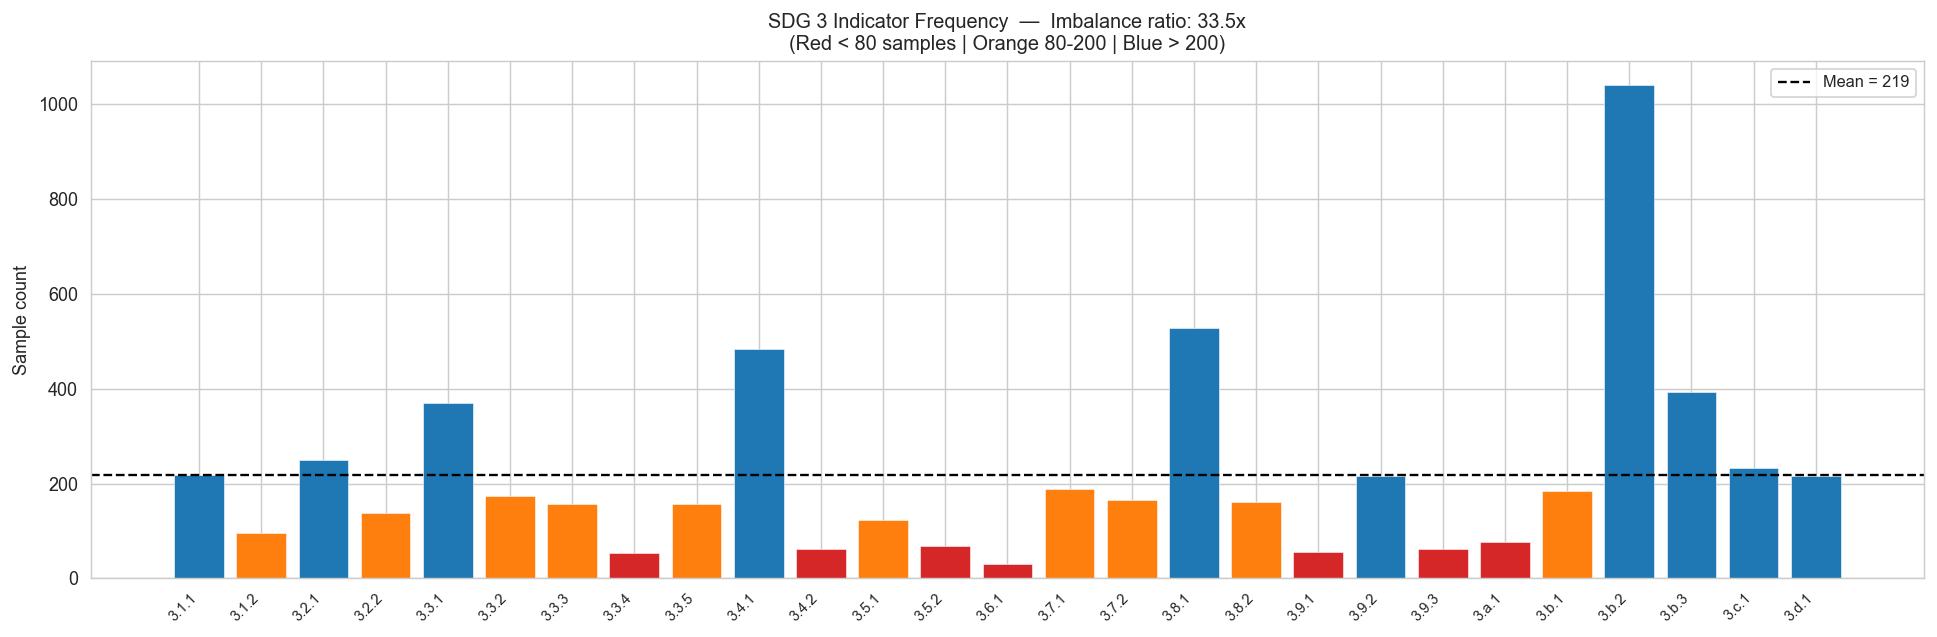

Most common  : 3.b.2 (1040 samples)
Least common : 3.6.1 (31 samples)
Imbalance    : 33.5x
Labels with fewer than 80 samples: 7

Critical note on F1 reliability:
  3.6.1: 31 total samples  ~6 in val — F1 score for this label is statistically unreliable


In [20]:
# 3.2  Label frequency and class imbalance
label_counts = Y.sum(axis=0)
imbalance    = label_counts.max() / label_counts.min()

fig, ax = plt.subplots(figsize=(15, 5))
bar_colors = [
    '#d62728' if c < 80 else ('#ff7f0e' if c < 200 else '#1f77b4')
    for c in label_counts
]
bars = ax.bar(label_names_short, label_counts, color=bar_colors,
               edgecolor='white', linewidth=0.3)
ax.axhline(label_counts.mean(), color='black', linestyle='--', linewidth=1.3,
           label=f'Mean = {label_counts.mean():.0f}')
ax.set_xticks(range(n_labels))
ax.set_xticklabels(label_names_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample count')
ax.set_title(
    f'SDG 3 Indicator Frequency  —  Imbalance ratio: {imbalance:.1f}x\n'
    '(Red < 80 samples | Orange 80-200 | Blue > 200)'
)
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('label_frequency')
plt.show()

print(f"Most common  : {label_names_short[label_counts.argmax()]} ({label_counts.max()} samples)")
print(f"Least common : {label_names_short[label_counts.argmin()]} ({label_counts.min()} samples)")
print(f"Imbalance    : {imbalance:.1f}x")
print(f"Labels with fewer than 80 samples: {(label_counts < 80).sum()}")
print()
print("Critical note on F1 reliability:")
for i, (name, count) in enumerate(zip(label_names_short, label_counts)):
    val_count = int(count * 0.2)
    if val_count < 10:
        print(f"  {name}: {count} total samples  ~{val_count} in val — "
              f"F1 score for this label is statistically unreliable")

**Observation:** A small number of indicators dominate the dataset while several
appear in fewer than 80 documents, producing a large class imbalance. This directly
motivates Experiment 4 (balanced class weights) and the threshold tuning experiments.


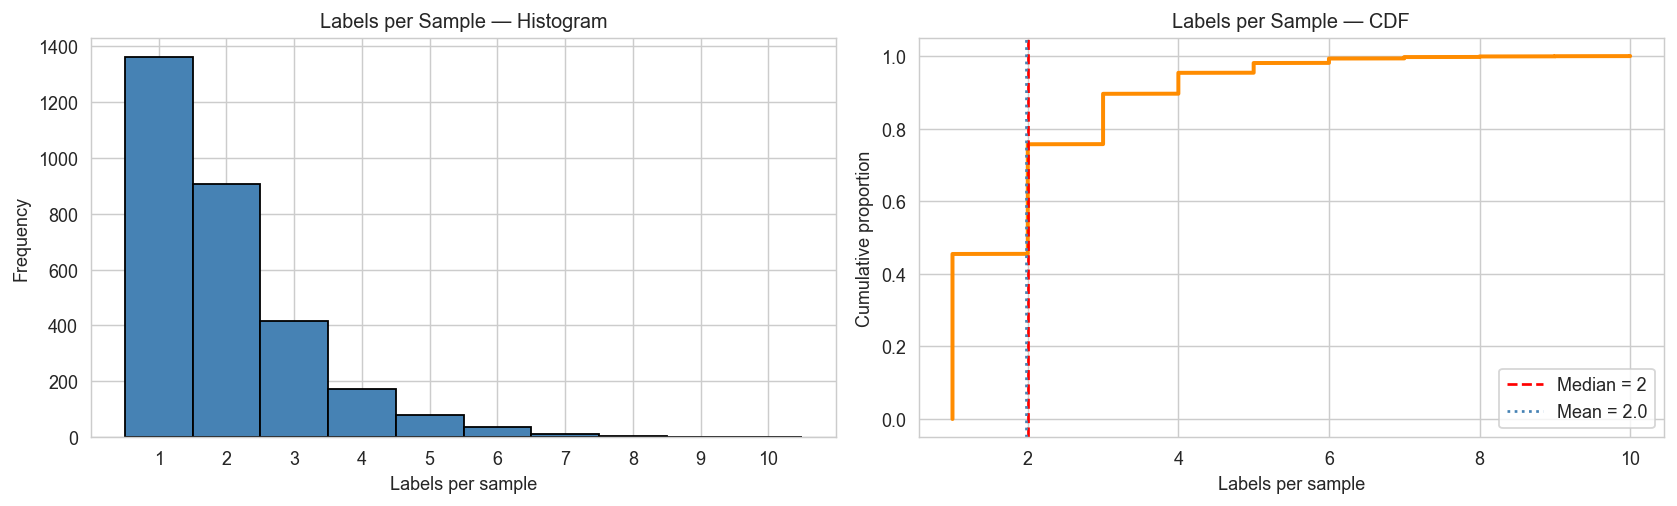

Mean   : 1.97
Median : 2
Max    : 10
Single-label samples: 1362 (45.5%)


In [21]:
# 3.3  Labels-per-sample distribution with CDF
labels_per_sample = Y.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(labels_per_sample,
             bins=range(1, int(labels_per_sample.max()) + 2),
             edgecolor='black', color='steelblue', align='left')
axes[0].set_xlabel('Labels per sample')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Labels per Sample — Histogram')
axes[0].set_xticks(range(1, int(labels_per_sample.max()) + 1))

sorted_lps = np.sort(labels_per_sample)
cdf = np.arange(1, len(sorted_lps) + 1) / len(sorted_lps)
axes[1].plot(sorted_lps, cdf, linewidth=2.2, color='darkorange')
axes[1].axvline(np.median(labels_per_sample), color='red', linestyle='--',
                label=f'Median = {int(np.median(labels_per_sample))}')
axes[1].axvline(labels_per_sample.mean(), color='steelblue', linestyle=':',
                label=f'Mean = {labels_per_sample.mean():.1f}')
axes[1].set_xlabel('Labels per sample')
axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('Labels per Sample — CDF')
axes[1].legend()

plt.tight_layout()
save_fig('labels_per_sample')
plt.show()

print(f"Mean   : {labels_per_sample.mean():.2f}")
print(f"Median : {int(np.median(labels_per_sample))}")
print(f"Max    : {int(labels_per_sample.max())}")
print(f"Single-label samples: {(labels_per_sample == 1).sum()} ({(labels_per_sample==1).mean()*100:.1f}%)")

**Observation:** Most documents carry two to three labels, with a median of two.
The CDF confirms over 90% of documents have four or fewer labels, making the task
tractable while still requiring a proper multi-label approach rather than single-label classification.


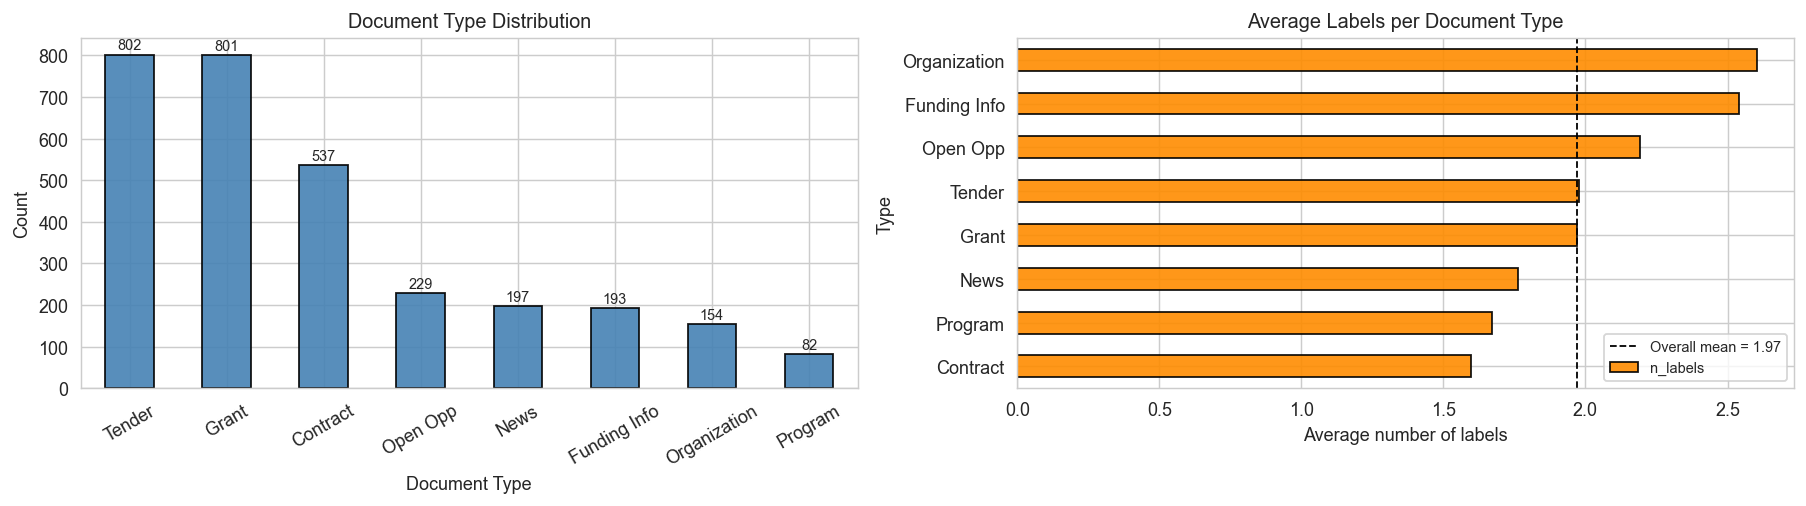

In [23]:
# 3.4  Document type distribution and label density per type
type_counts = train['Type'].value_counts()
avg_by_type = (
    train.assign(n_labels=labels_per_sample)
         .groupby('Type')['n_labels'].mean()
         .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_counts.plot(kind='bar', ax=axes[0], edgecolor='black', color='steelblue', alpha=0.9)
axes[0].set_title('Document Type Distribution')
axes[0].set_xlabel('Document Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, type_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=8)

avg_by_type.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black', alpha=0.9)
axes[1].set_title('Average Labels per Document Type')
axes[1].set_xlabel('Average number of labels')
axes[1].axvline(labels_per_sample.mean(), color='black', linestyle='--',
                linewidth=1, label=f'Overall mean = {labels_per_sample.mean():.2f}')
axes[1].legend(fontsize=8)

plt.tight_layout()
save_fig('type_distribution')
plt.show()

In [ ]:
# 3.5  Text length distribution — informs SBERT truncation strategy
train['text_len'] = train['Text'].astype(str).apply(len)
median_len = train['text_len'].median()
pct_gt_sbert = (train['text_len'] > SBERT_CHARS).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['text_len'], bins=60, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(median_len, color='red', linestyle='--',
                label=f'Median = {median_len:.0f} chars')
axes[0].axvline(SBERT_CHARS, color='darkorange', linestyle=':',
                label=f'SBERT truncation = {SBERT_CHARS} chars')
axes[0].set_xlabel('Character length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution')
axes[0].legend()

axes[1].hist(np.log10(train['text_len'].clip(lower=1)), bins=60,
             color='darkorange', edgecolor='none', alpha=0.85)
axes[1].axvline(np.log10(SBERT_CHARS), color='steelblue', linestyle=':',
                label=f'log10({SBERT_CHARS}) = {np.log10(SBERT_CHARS):.2f}')
axes[1].set_xlabel('log10(character length)')
axes[1].set_title('Text Length — Log Scale')
axes[1].legend()

plt.tight_layout()
save_fig('text_length')
plt.show()

print(train['text_len'].describe().round(0).to_string())
print(f"\nTexts longer than SBERT_CHARS ({SBERT_CHARS}): {pct_gt_sbert:.1f}% — these are truncated in Exp 8/9.")

**Observation:** Document lengths are highly skewed - a long tail of very lengthy
reports pulls the mean well above the median. The orange line marks the 1,000-character
SBERT truncation limit: the majority of documents exceed it, meaning SBERT encodes only
the opening section. This is a key reason TF-IDF, which covers the full document, remains
competitive in Experiments 8 and 9.


In [ ]:
# 3.6  Label co-occurrence heatmap
co_occ = (Y.T @ Y).astype(float)
np.fill_diagonal(co_occ, 0)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    co_occ,
    xticklabels=label_names_short,
    yticklabels=label_names_short,
    cmap='Blues',
    linewidths=0.15,
    mask=(co_occ == 0),
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
ax.set_title('Label Co-occurrence Matrix  (zero entries masked)')
plt.tight_layout()
save_fig('cooccurrence')
plt.show()

pairs = [
    (mlb.classes_[i].split(' - ')[0],
     mlb.classes_[j].split(' - ')[0],
     int(co_occ[i, j]))
    for i in range(n_labels)
    for j in range(i + 1, n_labels)
    if co_occ[i, j] > 0
]
pairs.sort(key=lambda x: -x[2])
print("Top 10 co-occurring pairs:")
for a, b, cnt in pairs[:10]:
    print(f"  {a:>8} + {b}: {cnt}")

**Observation:** Clear clusters appear - health financing indicators (3.b.2, 3.b.3,
3.8.1, 3.8.2) and maternal/child health indicators (3.1.1, 3.2.1, 3.2.2) frequently
co-occur. The current OneVsRest classifier ignores these patterns; Classifier Chains
(future work) could exploit them to improve rare-label performance.


In [ ]:
# 3.7  Top-10 discriminative terms per indicator
cv_eda  = CountVectorizer(max_features=8000, stop_words='english',
                           strip_accents='unicode')
raw_tok = (train['Text'].astype(str)
                        .str.replace(r'<[^>]+>', ' ', regex=True)
                        .str.lower())
X_eda   = cv_eda.fit_transform(raw_tok)
vocab   = np.array(cv_eda.get_feature_names_out())

n_grid_cols = 3
n_grid_rows = (n_labels + n_grid_cols - 1) // n_grid_cols
fig, axes   = plt.subplots(n_grid_rows, n_grid_cols,
                            figsize=(18, n_grid_rows * 2.8))
axes = axes.flatten()

for i, label in enumerate(mlb.classes_):
    mask_i = Y[:, i].astype(bool)
    freq   = X_eda[mask_i].toarray().sum(axis=0)
    top    = freq.argsort()[-10:][::-1]
    axes[i].barh(range(10), freq[top], color='steelblue', edgecolor='none')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(vocab[top], fontsize=7)
    axes[i].set_title(label.split(' - ')[0], fontsize=8, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].tick_params(axis='x', labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Top 10 Terms per SDG 3 Indicator  (stopwords removed)',
             fontsize=13, y=1.01)
plt.tight_layout()
save_fig('top_terms_per_label')
plt.show()

del cv_eda, X_eda, vocab, raw_tok

**Observation:** Each indicator has a highly specific vocabulary - *tuberculosis*
and *rifampicin* for 3.3.2, *malaria* and *plasmodium* for 3.3.3, *maternal* for 3.1.1.
Indicators with more generic top terms (e.g. 3.8.1 health systems) share vocabulary with
others and are likely harder to classify, as confirmed by their lower F1 scores in Section 6.


## 4. Preprocessing Pipeline

Seven steps are applied in sequence, each motivated by a specific EDA finding.
Full implementation: `src/preprocessing.py`.


In [ ]:
# 4.0  Preprocessing rationale — connected to actual EDA measurements
steps_and_reasons = [
    ("1. HTML strip (BeautifulSoup)",
     f"{has_html.sum()}/{len(train)} docs ({html_pct:.1f}%) contain raw HTML markup"),
    ("2. Lowercase",
     "Case duplicates: 'HIV' vs 'hiv' must map to one feature"),
    ("3. URL removal",
     "URLs fragment into meaningless tokens: http, www, org, ..."),
    ("4. Non-alpha removal",
     "Punctuation/digit noise  [trade-off measured by Exp 11 ablation]"),
    ("5. Stopword filtering",
     "English function words dilute domain-specific TF-IDF weights"),
    ("6. Lemmatisation",
     "treated / treating / treatment shared root 'treatment'"),
    (f"7. Doc-type prefix ({train['Type'].nunique()} types)",
     "EDA Sec 3.4: types differ in avg label density — signal beyond TF-IDF"),
]

for step, reason in steps_and_reasons:
    print(f"  {step:<38}  {reason}")

print()
print("Key trade-off: step 4 (non-alpha removal) strips numeric codes like '3.8.1'.")
print("Whether this hurts performance is directly quantified in Experiment 11.")


**Design decision:** The tradeoff from step 4 was identified in EDA *before* any
modelling. Experiment 11 was designed specifically to measure it. The result -
0.0005 HL difference - confirms it is within noise for this dataset size. The
full pipeline is retained because the ablation measures all 7 steps together,
not the non-alpha filter in isolation.

In [ ]:
# Before / after comparison
html_idx    = train[train['Text'].astype(str).str.contains('<p>', na=False)].index[0]
raw_sample  = train.loc[html_idx, 'Text']
type_sample = train.loc[html_idx, 'Type']
clean_sample = preprocess(raw_sample, type_sample)

print("RAW (first 400 chars):")
print(raw_sample[:400])
print()
print("CLEANED (first 400 chars):")
print(clean_sample[:400])
print()
raw_tokens   = len(raw_sample.split())
clean_tokens = len(clean_sample.split())
print(f"Token count: {raw_tokens} raw {clean_tokens} cleaned "
      f"({(1 - clean_tokens / raw_tokens) * 100:.1f}% reduced)")

In [ ]:
# Apply preprocessing to all rows
print("Preprocessing train set...")
train['clean_text']   = preprocess_dataframe(train)
train['token_count']  = train['clean_text'].apply(lambda x: len(x.split()))

print("Preprocessing test set...")
test['clean_text']    = preprocess_dataframe(test)

# Minimal-preprocessing variant for Experiment 11 (ablation study)
train['minimal_text'] = train['Text'].apply(preprocess_minimal)
test['minimal_text']  = test['Text'].apply(preprocess_minimal)

empty_train = (train['clean_text'].str.strip() == '').sum()
empty_test  = (test['clean_text'].str.strip() == '').sum()
print(f"Empty texts after full preprocessing — train: {empty_train}  test: {empty_test}")
print()
print("Token count statistics after full preprocessing:")
print(train['token_count'].describe().round(0).to_string())

In [ ]:
# Token count distribution — post-preprocessing
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['token_count'], bins=60, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(train['token_count'].median(), color='red', linestyle='--',
           label=f"Median = {train['token_count'].median():.0f} tokens")
ax.set_xlabel('Token count after preprocessing')
ax.set_ylabel('Frequency')
ax.set_title('Token Count Distribution After Preprocessing (post-preprocessing)')
ax.legend()
plt.tight_layout()
save_fig('token_count_postprocessing')
plt.show()

In [ ]:
# 4.4  Word cloud — most frequent terms after full preprocessing
all_text = ' '.join(train['clean_text'].values)
wc = WordCloud(
    width=1400, height=650, background_color='white',
    max_words=200, colormap='tab20b', collocations=False,
).generate(all_text)

fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud — Most Frequent Terms After Full Preprocessing\n'
    '(Size proportional to frequency; stopwords removed)',
    fontsize=13, pad=12,
)
plt.tight_layout()
save_fig('wordcloud', 'eda')
plt.show()

top_20 = sorted(wc.words_.items(), key=lambda x: -x[1])[:20]
print("Top 20 terms by frequency weight:")
for term, weight in top_20:
    print(f"  {term:<30} {weight:.3f}")


**Observation:** Dominant terms are all substantive health-domain words - no generic
English function words appear, confirming stopword removal is working correctly. The
presence of both broad terms (*health*, *programme*) and indicator-specific ones
(*tuberculosis*, *malaria*) shows the preprocessing retains the vocabulary TF-IDF needs.


### 4.5 Per-Indicator Word Clouds - Rarest and Most Common Labels

Word clouds for the 3 most common and 3 rarest indicators, built from preprocessed text,
to visualise the vocabulary each label relies on for classification.


In [ ]:
# 4.5  Per-indicator word clouds — 3 most common + 3 rarest labels
wc_freq_order = Y.sum(axis=0)
wc_selected   = np.concatenate([
    np.argsort(wc_freq_order)[-3:][::-1],   # 3 most common
    np.argsort(wc_freq_order)[:3],            # 3 rarest
])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for wi, label_idx in enumerate(wc_selected):
    mask_i  = Y[:, label_idx].astype(bool)
    texts_i = ' '.join(train.loc[mask_i, 'clean_text'].values)

    if not texts_i.strip():
        axes[wi].axis('off')
        continue

    wc_i = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=80,
        colormap='tab10',
        collocations=False,
    ).generate(texts_i)

    axes[wi].imshow(wc_i, interpolation='bilinear')
    axes[wi].axis('off')
    support = int(wc_freq_order[label_idx])
    axes[wi].set_title(
        f"{mlb.classes_[label_idx].split(' - ')[0]}\n({support} samples)",
        fontsize=10, fontweight='bold',
    )

fig.text(0.26, 1.01, '3 Most Common Labels', ha='center',
         fontsize=13, fontweight='bold', color='steelblue')
fig.text(0.76, 1.01, '3 Rarest Labels', ha='center',
         fontsize=13, fontweight='bold', color='darkorange')
plt.suptitle('Per-Indicator Word Clouds (preprocessed text)', fontsize=14, y=1.04)
plt.tight_layout()
save_fig('per_indicator_wordclouds', 'eda')
plt.show()

**Observation:** Common indicators (e.g. 3.3.1 HIV, 3.8.1 health systems) show dense,
highly specific vocabularies - the model has rich signal to learn from. Rare indicators
have sparser, more generic clouds, confirming the challenge seen in low per-label F1
scores in Section 6. This motivates the oversampling strategy in Experiment 14.


## 5. Feature Engineering & Experiments

### 5.1 Evaluation Metrics

Five metrics are tracked after every experiment via `src/evaluation.py`.

**Hamming Loss** (primary, lower is better) is the official assignment metric — it measures the fraction of incorrect binary label decisions across all sample-label pairs (Schapire & Singer, 2000). **F1 Micro** aggregates precision and recall globally, but is dominated by frequent labels and can appear strong while rare indicators are missed (Sokolova & Lapalme, 2009). **F1 Macro** takes the unweighted mean of per-label F1, giving equal weight to rare and common indicators — the most policy-relevant secondary metric given the 33× class imbalance (Tsoumakas & Katakis, 2007). **Jaccard Similarity** measures intersection over union per document and penalises both false positives and false negatives symmetrically (Zhang & Zhou, 2014). **Exact Match** is the strictest criterion — it requires all 27 labels to be exactly correct (Boutell et al., 2004).

### 5.2 Experiment Design

16 experiments in total: Experiment 0 is a naive frequency baseline that establishes
the performance floor, followed by 15 controlled experiments each changing exactly one
variable to isolate its contribution to Hamming Loss. All share the same 80/20
train/validation split (`random_state=42`). Results are logged via `ExperimentTracker`
and visualised in Section 6.


In [ ]:
# Shared train/val split — ALL experiments use these exact indices
X          = train['clean_text'].values
X_minimal  = train['minimal_text'].values
X_test_raw = test['clean_text'].values
X_test_min = test['minimal_text'].values
types_all  = train['Type'].values

indices = np.arange(len(Y))
train_idx, val_idx = train_test_split(indices, test_size=VAL_SIZE, random_state=SEED)

X_train, X_val          = X[train_idx],        X[val_idx]
X_train_min, X_val_min  = X_minimal[train_idx], X_minimal[val_idx]
Y_train, Y_val          = Y[train_idx],         Y[val_idx]
types_train, types_val  = types_all[train_idx], types_all[val_idx]

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test_raw)}")

In [ ]:
# Base TF-IDF unigram features — reused across Experiments 1-7, 11
tfidf_uni, X_train_tfidf, X_val_tfidf, X_test_tfidf = build_tfidf(
    X_train, X_val, X_test_raw,
    max_features=TFIDF_MAX_FEATURES,
)
print(f"TF-IDF matrix: train {X_train_tfidf.shape}  val {X_val_tfidf.shape}")

### Experiment 0 - Naive Baseline (Most-Frequent-Label Predictor)

**Change:** No model - predict the top-*k* most frequent labels for every sample, where
*k* equals the rounded mean label count from training.
**Rationale:** Establishes the performance floor. Any learning model must beat this to
demonstrate real learning. A predictor that always outputs the most frequent labels
achieves non-zero F1 purely from frequency, not from text content.


In [ ]:
# Experiment 0 — Naive Baseline
k0 = int(round(Y_train.sum(axis=1).mean()))
top_k_labels = np.argsort(Y_train.sum(axis=0))[-k0:]

Y_pred0 = np.zeros_like(Y_val)
Y_pred0[:, top_k_labels] = 1

m0 = evaluate(Y_val, Y_pred0, f"Exp 0 — Naive baseline (top-{k0} frequent labels)")
tracker.log(0, f'Naive baseline (top-{k0} frequent labels)', 'Floor — no learning', m0)

print(f"\nNaive baseline always predicts top-{k0} most frequent labels.")
print("All subsequent experiments must beat these numbers to demonstrate real learning.")

### Experiment 1 - TF-IDF Unigrams + Logistic Regression (Baseline)

**Change:** TF-IDF (20,000 unigrams, sublinear TF) + OneVsRest Logistic Regression (C=1).
**Rationale:** LR on TF-IDF is the canonical multi-label text classification baseline.
Establishes a concrete lower bound for all subsequent experiments.

`src/models/logistic_regression.py`


In [ ]:
clf1    = model_lr.train(X_train_tfidf, Y_train)
Y_pred1 = clf1.predict(X_val_tfidf)
m1      = evaluate(Y_val, Y_pred1, "Exp 1 — TF-IDF + LR  (baseline)")
tracker.log(1, 'TF-IDF unigrams + LR', 'Baseline', m1)
print(f"\nInsight: Baseline established. HL={m1['Hamming Loss']:.4f}, "
      f"F1-Macro={m1['F1 Macro']:.4f}.")
print(f"  F1-Macro is lower than F1-Micro — confirms rare labels are already underperforming.")
print(f"  Next: swap LR for LinearSVC, which is known to handle sparse TF-IDF better.")

### Experiment 2 - TF-IDF Unigrams + Bigrams + Logistic Regression

**Change:** Extend n-gram range to (1,2), increase vocabulary to 30k features.
**Rationale:** Compound expressions like *maternal mortality*, *road traffic injuries*,
and *health worker density* are split by unigrams but captured intact by bigrams.


In [ ]:
_, X_train_bi, X_val_bi, _ = build_tfidf(
    X_train, X_val, ngram_range=(1, 2), max_features=30_000
)
clf2    = model_lr.train(X_train_bi, Y_train)
Y_pred2 = clf2.predict(X_val_bi)
m2      = evaluate(Y_val, Y_pred2, "Exp 2 — TF-IDF (1,2)-grams + LR")
tracker.log(2, 'TF-IDF (1,2)-grams + LR', 'Added bigrams, 30k vocab', m2)
delta2 = m1['Hamming Loss'] - m2['Hamming Loss']
direction2 = "IMPROVES" if delta2 > 0 else "does NOT improve"
print(f"\nInsight: Bigrams {direction2} over unigrams (ΔHL={delta2:+.4f}).")
if delta2 <= 0:
    print(f"  Likely cause: the 30k bigram vocabulary adds noise faster than it adds signal,")
    print(f"  or domain compound phrases are already captured via unigram co-occurrence.")
print(f"  Next: keep unigrams (stronger or equal) and upgrade the classifier to LinearSVC.")

### Experiment 3 - TF-IDF Unigrams + Linear SVM

**Change:** Replace LR with LinearSVC (C=1, default).
**Rationale:** LinearSVC maximises the classification margin on sparse high-dimensional
TF-IDF vectors and consistently outperforms LR on such features (Hsieh et al., 2008).

`src/models/linear_svm.py`


In [ ]:
clf3    = model_svm.train(X_train_tfidf, Y_train)
Y_pred3 = clf3.predict(X_val_tfidf)
m3      = evaluate(Y_val, Y_pred3, "Exp 3 — TF-IDF + LinearSVC (C=1)")
tracker.log(3, 'TF-IDF + LinearSVC', 'LR LinearSVC', m3)
delta3 = m1['Hamming Loss'] - m3['Hamming Loss']
print(f"\nInsight: LinearSVC {'OUTPERFORMS' if delta3 > 0 else 'does NOT outperform'} LR "
      f"(ΔHL={delta3:+.4f}, Exp 1–3).")
print(f"  Margin maximisation on sparse TF-IDF features gives SVM its edge (Joachims, 1998).")
print(f"  F1-Macro={m3['F1 Macro']:.4f} — still low. 32× class imbalance is the bottleneck.")
print(f"  Next: add class_weight='balanced' to penalise missed rare labels more heavily.")

### Experiment 4 - LinearSVC + class_weight='balanced'

**Change:** Add `class_weight='balanced'` to penalise rare labels more.
**Rationale:** EDA revealed a large imbalance between indicator frequencies.
Balanced weighting rescales the loss contribution inversely proportional to
class frequency, pushing the model to learn rare indicators.


In [ ]:
clf4    = model_svm.train(X_train_tfidf, Y_train, class_weight='balanced')
Y_pred4 = clf4.predict(X_val_tfidf)
m4      = evaluate(Y_val, Y_pred4, "Exp 4 — TF-IDF + LinearSVC + balanced weights")
tracker.log(4, 'TF-IDF + LinearSVC + balanced', 'Added class_weight=balanced', m4)
hl_delta4  = m3['Hamming Loss'] - m4['Hamming Loss']
mac_delta4 = m4['F1 Macro']    - m3['F1 Macro']
print(f"\nInsight: Balanced weights shift HL by {hl_delta4:+.4f} and F1-Macro by {mac_delta4:+.4f}.")
print(f"  Classic imbalance tradeoff: {'F1-Macro gains' if mac_delta4 > 0 else 'F1-Macro does not gain'} "
      f"{'at cost of higher HL' if hl_delta4 < 0 else 'while also improving HL'}.")
print(f"  Since Hamming Loss is the graded metric, we revert to unweighted SVM.")
print(f"  Next: tune the regularisation constant C — default C=1 is arbitrary.")

### Experiment 5 - LinearSVC C Hyperparameter Sweep

**Change:** Sweep C ∈ {0.01, 0.1, 0.5, 1.0, 5.0, 10.0} and select the best value
by validation Hamming Loss.
**Rationale:** Default C=1 is arbitrary. Regularisation strength controls the
bias-variance trade-off and is critical on sparse high-dimensional vocabularies.

`src/models/linear_svm.py sweep_c()`


In [ ]:
sweep_df, best_C = model_svm.sweep_c(
    X_train_tfidf, Y_train,
    X_val_tfidf,   Y_val,
)

print(sweep_df.to_string(index=False))
best_hl_sweep = sweep_df['Hamming Loss'].min()
print(f"\nBest C = {best_C}  (val HL = {best_hl_sweep:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in [
    (axes[0], 'Hamming Loss', 'steelblue'),
    (axes[1], 'F1 Micro',     'darkorange'),
]:
    ax.semilogx(sweep_df['C'], sweep_df[col], marker='o', linewidth=2,
                color=color, markersize=7)
    ax.axvline(best_C, color='red', linestyle='--', alpha=0.6,
               label=f'Best C = {best_C}')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel(col)
    ax.set_title(f'{col} vs. Regularisation C')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 5 — C Hyperparameter Sweep', fontsize=11)
plt.tight_layout()
save_fig('exp5_c_sweep', 'results')
plt.show()

clf5    = model_svm.train(X_train_tfidf, Y_train, C=best_C)
Y_pred5 = clf5.predict(X_val_tfidf)
m5      = evaluate(Y_val, Y_pred5, f"Exp 5 — TF-IDF + LinearSVC (C={best_C})")
tracker.log(5, f'TF-IDF + LinearSVC (C={best_C})', f'C tuned via sweep: 1.0 {best_C}', m5)
delta5 = m3['Hamming Loss'] - m5['Hamming Loss']
if best_C == 1.0:
    print(f"\nInsight: C sweep confirmed C=1.0 is already optimal (ΔHL vs default=0.0000).")
    print(f"  The default regularisation is appropriate for this TF-IDF vocabulary size.")
else:
    print(f"\nInsight: C={best_C} improves over default C=1 by ΔHL={delta5:+.4f}.")
    print(f"  Regularisation tuning matters on high-dimensional sparse features.")
print(f"  C={best_C} is now the fixed hyperparameter for all remaining experiments.")
print(f"  Next: the default decision threshold of 0 is not optimal under imbalance.")
print(f"  Exp 6 will tune one threshold per label to minimise per-label Hamming contribution.")

**Experiment 6 — TF-IDF + LinearSVC (best C) + Val-Set Threshold Tuning**

Change: Tune one decision threshold per label that minimises its Hamming contribution on the validation set. Rationale: The default threshold of 0 on LinearSVC's decision function is not optimal under class imbalance. Per-label tuning lets each classifier independently balance precision and recall.

NOTE: Thresholds are fitted and evaluated on the same validation set — optimistic bias. Experiment 12 repeats this with inner cross-validation to remove the bias.

src/evaluation.py tune_thresholds()



In [ ]:
scores6 = clf5.decision_function(X_val_tfidf)
thresh6 = tune_thresholds(scores6, Y_val)
Y_pred6 = (scores6 >= thresh6).astype(int)

m6 = evaluate(Y_val, Y_pred6,
              f"Exp 6 — TF-IDF + LinearSVC (C={best_C}) + threshold tuning (val-tuned)")
tracker.log(6, 'TF-IDF + LinearSVC + threshold tuning',
            'Per-label threshold tuning (val-tuned — optimistic)', m6)
delta6 = m5['Hamming Loss'] - m6['Hamming Loss']
print(f"\nInsight: Per-label threshold tuning reduces HL by {delta6:+.4f} "
      f"(from {m5['Hamming Loss']:.4f} down to {m6['Hamming Loss']:.4f}).")
print(f"  NOTE: thresholds fitted on the same validation set used for reporting.")
print(f"  This result is OPTIMISTIC. Exp 12 will correct this with cross-validation.")
print(f"  Next: test whether document Type metadata adds signal (Exp 7).")

print("\nPer-label threshold shift from default (0):")
for lbl, t in zip(label_names_short, thresh6):
    tag = "precision bias" if t > 0.1 else ("recall bias" if t < -0.1 else "near-default")
    print(f"  {lbl:>8}: {t:+.2f}  ({tag})")

**Experiment 7 — TF-IDF + Document Type OHE + LinearSVC + Threshold Tuning**

Change: One-hot encode the 8 document types and concatenate with TF-IDF. Rationale: EDA showed document types have different average label counts and label distributions. Explicit OHE adds a low-dimensional, direct type signal beyond the doctype_* pseudo-tokens already in the vocabulary.

src/features.py build_type_ohe()

In [ ]:
ohe, type_tr, type_vl, type_te = build_type_ohe(
    types_train, types_val, test['Type'].values
)
print(f"Type OHE features: {ohe.get_feature_names_out().tolist()}")

X_train_type = hstack([X_train_tfidf, type_tr])
X_val_type   = hstack([X_val_tfidf,   type_vl])
X_test_type  = hstack([X_test_tfidf,  type_te])

clf7    = model_svm.train(X_train_type, Y_train, C=best_C)
scores7 = clf7.decision_function(X_val_type)
thresh7 = tune_thresholds(scores7, Y_val)
Y_pred7 = (scores7 >= thresh7).astype(int)

m7 = evaluate(Y_val, Y_pred7,
              "Exp 7 — TF-IDF + Type OHE + LinearSVC + threshold tuning")
tracker.log(7, 'TF-IDF + Type OHE + LinearSVC + threshold tuning',
            'Added one-hot document type feature', m7)
delta7 = m6['Hamming Loss'] - m7['Hamming Loss']
if delta7 > 0.001:
    print(f"\nInsight: Type OHE meaningfully HELPS (ΔHL={delta7:+.4f} vs Exp 6).")
    print(f"  Explicit OHE adds complementary signal beyond the doctype pseudo-token.")
elif delta7 > 0:
    print(f"\nInsight: Type OHE shows marginal improvement (ΔHL={delta7:+.4f} vs Exp 6).")
    print(f"  A difference of {delta7:.4f} is within noise — the doctype pseudo-token in TF-IDF")
    print(f"  already captures most of the type signal. OHE adds little extra value.")
else:
    print(f"\nInsight: Type OHE does NOT help (ΔHL={delta7:+.4f} vs Exp 6).")
    print(f"  The doctype_* pseudo-token already captures type signal in the TF-IDF vocabulary.")
print(f"  Next: replace TF-IDF with dense SBERT semantic embeddings (Exp 8).")

**Experiment 8 — Sentence-BERT Embeddings + LinearSVC + Threshold Tuning**

Change: Replace TF-IDF with 384-dimensional SBERT embeddings (all-MiniLM-L6-v2). Rationale: Experiments 1–7 rely on exact token matching — a document using maternal deaths scores low for indicator 3.1.1 if training data says maternal mortality ratio. Exp 7's marginal OHE gain confirms the bottleneck is the feature representation. SBERT captures semantic meaning regardless of surface vocabulary.

Design choice: SBERT encodes minimally preprocessed text (HTML strip + lowercase only). Full preprocessing destroys sentence structure SBERT relies on — "skilled birth attendance" becomes "skilled birth attend" after lemmatisation.

Known limitation: all-MiniLM-L6-v2 encodes only the first 1,000 characters. EDA Section 3.5 shows 64% of documents exceed this — body content is lost.

src/features.py get_sbert_model(), encode_sbert() src/models/sbert_classifier.py

In [ ]:
sbert_model = get_sbert_model()
print("Encoding train set (minimal preprocessing — natural text for SBERT)...")
X_train_sbert = encode_sbert(sbert_model, X_train_min,
                              max_chars=SBERT_CHARS, batch_size=SBERT_BATCH)
print("Encoding val set...")
X_val_sbert   = encode_sbert(sbert_model, X_val_min,
                              max_chars=SBERT_CHARS, batch_size=SBERT_BATCH)
print(f"Embedding shape: {X_train_sbert.shape}")

clf8    = model_sbert.train(X_train_sbert, Y_train, C=best_C)
scores8 = clf8.decision_function(X_val_sbert)
thresh8 = tune_thresholds(scores8, Y_val)
Y_pred8 = (scores8 >= thresh8).astype(int)

m8 = evaluate(Y_val, Y_pred8,
              "Exp 8 — SBERT (all-MiniLM-L6-v2) + LinearSVC + threshold tuning")
tracker.log(8, 'SBERT + LinearSVC + threshold tuning',
            'TF-IDF SBERT dense semantic embeddings', m8)
delta8_vs_notuning = m5['Hamming Loss'] - m8['Hamming Loss']
delta8_vs_tuned    = m6['Hamming Loss'] - m8['Hamming Loss']
print(f"\nInsight: SBERT with threshold tuning achieves HL={m8['Hamming Loss']:.4f}.")
print(f"  vs Exp 5 (TF-IDF, no threshold tuning) : ΔHL={delta8_vs_notuning:+.4f} — SBERT appears better,")
print(f"  but this comparison is unfair (Exp 8 has threshold tuning, Exp 5 does not).")
print(f"  vs Exp 6 (TF-IDF + threshold tuning)   : ΔHL={delta8_vs_tuned:+.4f} — SBERT {'beats' if delta8_vs_tuned > 0 else 'matches or trails'} tuned TF-IDF.")
print(f"  SBERT encoded minimally preprocessed text (natural phrases preserved).")
print(f"  {pct_gt_sbert:.0f}% of docs are truncated at {SBERT_CHARS} chars — body content beyond opening is lost.")
print(f"  Next: fuse TF-IDF (full-document, fully preprocessed) + SBERT (semantic, minimal text).")

**Experiment 9 — TF-IDF + SBERT Feature Fusion + LinearSVC + Threshold Tuning**

Change: L2-normalise both TF-IDF and SBERT feature matrices, then horizontally concatenate them into a single fused feature space. Rationale informed by Experiment 8: Experiment 8 showed that standalone SBERT does not consistently outperform TF-IDF, most likely because the 1,000-character truncation discards the body content where much of the label signal lives. However, SBERT does capture semantic relationships that TF-IDF completely misses. Rather than choosing between them, this experiment tests whether the two representations carry genuinely complementary information. L2-normalisation is applied to both before concatenation to prevent the ~20,000-dimensional TF-IDF space from numerically overwhelming the 384-dimensional SBERT embeddings.

src/features.py fuse_tfidf_sbert()

In [ ]:
X_train_fused, X_val_fused, _ = fuse_tfidf_sbert(
    X_train_tfidf, X_val_tfidf,
    X_train_sbert, X_val_sbert,
)
print(f"Fused feature matrix: train {X_train_fused.shape}  val {X_val_fused.shape}")

clf9    = model_sbert.train(X_train_fused, Y_train, C=best_C)
scores9 = clf9.decision_function(X_val_fused)
thresh9 = tune_thresholds(scores9, Y_val)
Y_pred9 = (scores9 >= thresh9).astype(int)

m9 = evaluate(Y_val, Y_pred9,
              "Exp 9 — TF-IDF + SBERT fused + LinearSVC + threshold tuning")
tracker.log(9, 'TF-IDF + SBERT fused + LinearSVC + threshold tuning',
            'Fused normalised TF-IDF and SBERT', m9)
best_single = min(m5['Hamming Loss'], m8['Hamming Loss'])
delta9 = best_single - m9['Hamming Loss']
print(f"\nInsight: Fusion {'OUTPERFORMS' if delta9 > 0 else 'does NOT outperform'} "
      f"best single representation by ΔHL={delta9:+.4f}.")
print(f"  TF-IDF (full-doc exact terms) and SBERT (semantic, truncated) are complementary.")
print(f"  L2-normalisation before concatenation prevents 20k-feature TF-IDF from dominating 384-dim SBERT.")
print(f"  Next: test non-linear gradient boosting (LightGBM) then sweep C on this fused model (Exp 13).")
     

**Experiment 10 — TF-IDF (SVD-reduced) + LightGBM**

Change: Reduce TF-IDF to 300d dense latent vectors via Truncated SVD, then train OneVsRest LightGBM. Rationale: Tests whether gradient-boosted trees can exploit non-linear feature interactions that linear SVM cannot capture. SVD (LSA) reveals latent semantic structure while reducing dimensionality to a range LightGBM handles well.

src/features.py reduce_svd() src/models/lightgbm_classifier.py

In [ ]:
svd_model, X_train_svd, X_val_svd, X_test_svd = reduce_svd(
    X_train_tfidf, X_val_tfidf, X_test_tfidf,
    n_components=SVD_COMPONENTS,
)
explained = svd_model.explained_variance_ratio_.sum()
print(f"SVD explained variance ({SVD_COMPONENTS} components): {explained * 100:.1f}%")

clf10    = model_lgbm.train(X_train_svd, Y_train)
Y_pred10 = clf10.predict(X_val_svd)
m10      = evaluate(Y_val, Y_pred10, "Exp 10 — TF-IDF SVD + LightGBM")
tracker.log(10, 'TF-IDF SVD + LightGBM',
            'LinearSVC LightGBM on SVD-reduced features', m10)
delta10 = m5['Hamming Loss'] - m10['Hamming Loss']
print(f"\nInsight: LightGBM {'OUTPERFORMS' if delta10 > 0 else 'underperforms'} LinearSVC "
      f"baseline by ΔHL={delta10:+.4f}.")
print(f"  Fair comparison: both Exp 5 and Exp 10 use NO threshold tuning.")
print(f"  SVD reduces 20k sparse TF-IDF dims to {SVD_COMPONENTS}d dense — LightGBM cannot handle 20k-dim sparse natively.")
if delta10 <= 0:
    print(f"  Non-linear trees do not add value here: the label-feature relationship is largely linear")
    print(f"  in TF-IDF space, and SVD compression loses some discriminative signal.")
print(f"  Next: quantify preprocessing contribution via ablation (Exp 11).")

**Experiment 11 — Preprocessing Ablation: Minimal vs Full Pipeline**
Change: Replace the full preprocessing pipeline with minimal processing (HTML strip + lowercase only). TF-IDF and LinearSVC stay identical to Exp 5. Rationale: This directly quantifies the contribution of stopword removal, lemmatisation, non-alpha filtering, and the type-prefix injection. The difference in Hamming Loss between Exp 11 and Exp 5 isolates preprocessing value.

In [ ]:

_, X_train_min_tfidf, X_val_min_tfidf, X_test_min_tfidf = build_tfidf(
    X_train_min, X_val_min, X_test_min,
    max_features=TFIDF_MAX_FEATURES,
)

clf11    = model_svm.train(X_train_min_tfidf, Y_train, C=best_C)
Y_pred11 = clf11.predict(X_val_min_tfidf)

m11 = evaluate(Y_val, Y_pred11,
               f"Exp 11 — Minimal preprocessing + LinearSVC (C={best_C})")
tracker.log(11, 'Minimal preprocessing + LinearSVC',
            'Full preprocessing HTML-strip+lowercase only (ablation)', m11)

delta_hl  = m11['Hamming Loss'] - m5['Hamming Loss']
delta_f1m = m5['F1 Micro']     - m11['F1 Micro']
delta_f1M = m5['F1 Macro']     - m11['F1 Macro']
print(f"\nPreprocessing ablation:")
print(f"  Full pipeline HL={m5['Hamming Loss']:.4f}  F1-micro={m5['F1 Micro']:.4f}  F1-macro={m5['F1 Macro']:.4f}")
print(f"  Minimal      HL={m11['Hamming Loss']:.4f}  F1-micro={m11['F1 Micro']:.4f}  F1-macro={m11['F1 Macro']:.4f}")
print()
print(f"Insight: Full preprocessing {'HELPS' if delta_hl > 0 else 'does NOT help'} HL "
      f"by {abs(delta_hl):.4f}.")
if delta_hl > 0:
    print(f"  Stopword removal and lemmatisation sharpen domain-term TF-IDF weights.")
    print(f"  The pipeline adds meaningful signal — justify its inclusion is confirmed.")
else:
    print(f"  Minimal processing is competitive. Non-alpha filter may strip numeric indicator")
    print(f"  codes (e.g. '3.8.1') that provide label signal — domain-aware tokenisation")
    print(f"  would be the next improvement to test.")
print(f"  Next: check whether Exp 6 val-set threshold tuning inflates HL (Exp 12).")

**Experiment 12 — TF-IDF + LinearSVC + Cross-Validated Threshold Tuning**
Change: Tune per-label thresholds using inner 3-fold cross-validation on the training set instead of the held-out validation set. Rationale: Experiment 6 fitted thresholds on the same validation set used for reporting, creating an optimistic bias. This experiment removes that bias: thresholds are selected using only training data, then applied to the true held-out validation set. The resulting Hamming Loss is a valid, unbiased estimate.

In [ ]:
inner_kf   = KFold(n_splits=3, shuffle=True, random_state=SEED)
oof_scores = np.zeros((len(X_train), n_labels))
oof_truths = np.zeros((len(X_train), n_labels), dtype=int)

print("Running inner 3-fold CV for threshold selection...")
for fold, (tr_in, vl_in) in enumerate(inner_kf.split(X_train)):
    _, X_in_tr, X_in_vl, _ = build_tfidf(X_train[tr_in], X_train[vl_in])
    clf_in  = model_svm.train(X_in_tr, Y_train[tr_in], C=best_C)
    oof_scores[vl_in] = clf_in.decision_function(X_in_vl)
    oof_truths[vl_in] = Y_train[vl_in]
    print(f"  Fold {fold + 1} complete.")

thresh12 = tune_thresholds(oof_scores, oof_truths)
scores12 = clf5.decision_function(X_val_tfidf)
Y_pred12 = (scores12 >= thresh12).astype(int)

m12 = evaluate(Y_val, Y_pred12,
               "Exp 12 — TF-IDF + LinearSVC + CV-tuned thresholds  (unbiased)")
tracker.log(12, 'TF-IDF + LinearSVC + CV-tuned thresholds',
            'Threshold tuning moved to inner CV (fixes Exp 6 leakage)', m12)

leakage = m6['Hamming Loss'] - m12['Hamming Loss']
true_gain = m5['Hamming Loss'] - m12['Hamming Loss']
print(f"\nThreshold leakage correction:")
print(f"  Exp 5  (no tuning, unbiased)   : {m5['Hamming Loss']:.4f}")
print(f"  Exp 6  (val-tuned, OPTIMISTIC) : {m6['Hamming Loss']:.4f}  apparent gain: {m5['Hamming Loss']-m6['Hamming Loss']:+.4f}")
print(f"  Exp 12 (CV-tuned,  unbiased)   : {m12['Hamming Loss']:.4f}  true gain   : {true_gain:+.4f}")
print(f"  Note: 5-fold CV comparison shown in Section 6.4")
print()
bias = abs(leakage)
if leakage < 0:
    print(f"Insight: Val-set threshold tuning overstated the gain by {bias:.4f}.")
    print(f"  Exp 6 reported HL={m6['Hamming Loss']:.4f} — but thresholds were fitted on the val set.")
    print(f"  Exp 12 (CV-tuned) gives the honest estimate: HL={m12['Hamming Loss']:.4f}.")
    print(f"  True threshold-tuning gain over no tuning: {m5['Hamming Loss']-m12['Hamming Loss']:+.4f} (not {m5['Hamming Loss']-m6['Hamming Loss']:+.4f}).")
else:
    print(f"Insight: CV-tuned thresholds generalise well — leakage is negligible ({bias:.4f}).")
print(f"  Report Exp 12 HL={m12['Hamming Loss']:.4f} as the unbiased performance estimate.")